In [1]:
import tensorflow as tf
from tensorflow import keras

In [2]:
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  0


In [3]:
tf.test.is_built_with_cuda()

True

In [4]:
print(tf.version.VERSION)

2.3.0


In [5]:
import sys
sys.version

'3.7.12 | packaged by conda-forge | (default, Oct 26 2021, 05:35:01) [MSC v.1916 64 bit (AMD64)]'

In [6]:
tf.config.list_physical_devices('GPU')

[]

In [7]:
tf.config.list_physical_devices('GPU')

[]

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras.applications import VGG16
from keras import backend as K

# Set seed value for NumPy
np.random.seed(42)

# Set seed value for TensorFlow
tf.random.set_seed(42)

In [25]:
# Function to compute class weights
def compute_class_weights(y):
    class_weights = {}
    for class_label in np.unique(y):
        class_weights[class_label] = len(y) / (len(np.where(y == class_label)[0]) * len(np.unique(y)))
    return class_weights

In [7]:
# Load the training data
train_df = pd.read_csv("./Dataset/train.csv")

In [8]:
# Update the 'id_code' column to include the file extension
train_df['id_code'] = train_df['id_code'].astype(str) + ".png"

In [9]:
# Convert the "diagnosis" column to string
train_df['diagnosis'] = train_df['diagnosis'].astype(str)

In [10]:
# Display the first few rows of the dataframe
print(train_df.head())

            id_code diagnosis
0  000c1434d8d7.png         2
1  001639a390f0.png         4
2  0024cdab0c1e.png         1
3  002c21358ce6.png         0
4  005b95c28852.png         0


In [11]:
# Split the data into training, validation, and hold-out test sets
train_data, test_data = train_test_split(train_df, test_size=0.2, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.2, random_state=42)

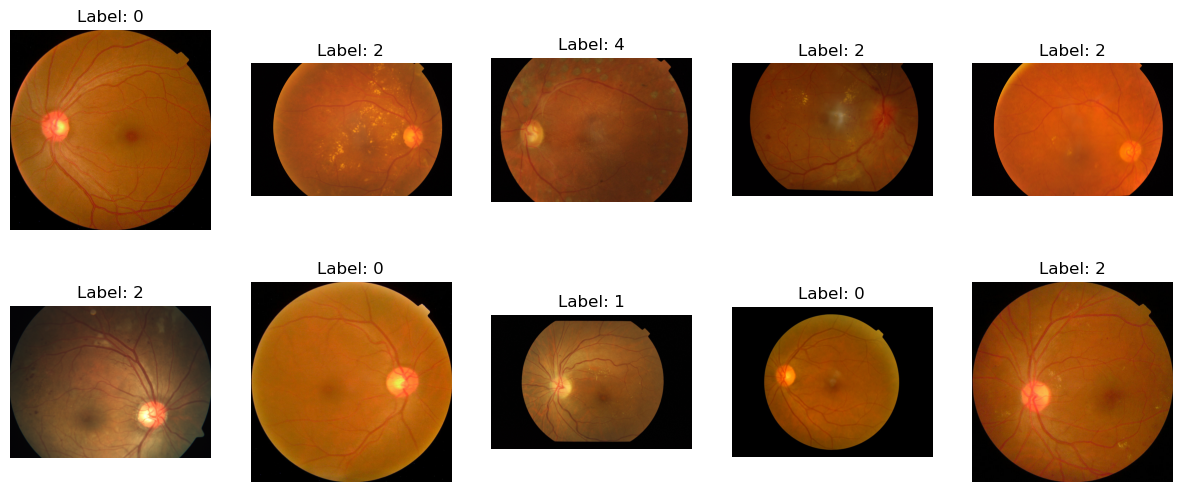

In [12]:
# Visualize a few original images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    img_path = f"./Dataset/train_images/{train_data['id_code'].iloc[i]}"
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {train_data['diagnosis'].iloc[i]}")

plt.show()

# Train and Validation Generator

In [13]:
# Data preprocessing and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [14]:
val_datagen = ImageDataGenerator(rescale=1./255)

In [15]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory="./Dataset/train_images/",
    x_col="id_code",
    y_col="diagnosis",
    target_size=(256, 256),
    batch_size=32,
    class_mode="categorical"
)

Found 2334 validated image filenames belonging to 5 classes.


C:\Users\MSI\anaconda3\envs\DataAnalytics\lib\site-packages\keras_preprocessing\image\dataframe_iterator.py:282: UserWarning: Found 9 invalid image filename(s) in x_col="id_code". These filename(s) will be ignored.
  .format(n_invalid, x_col)


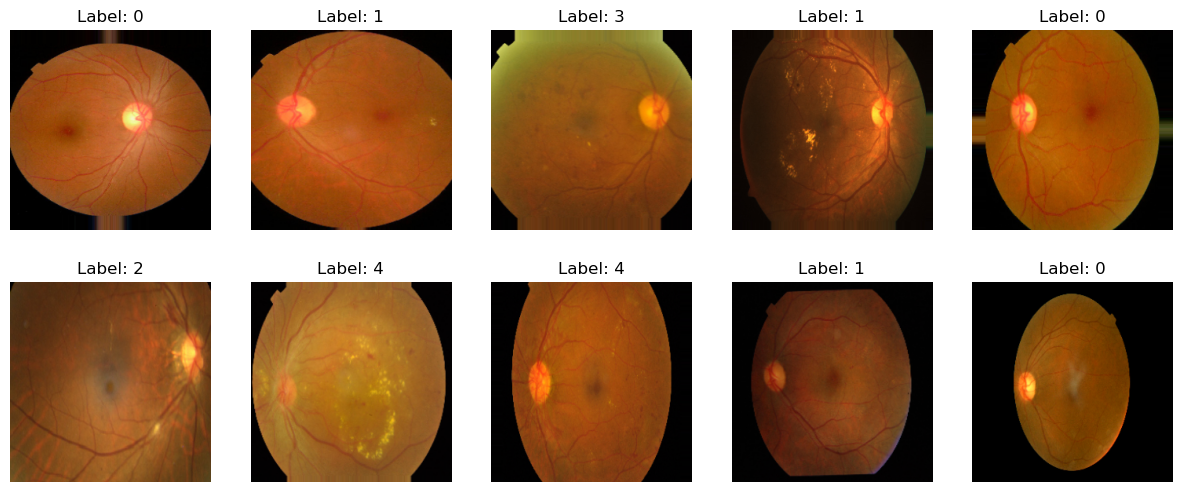

In [16]:
# Visualize a few augmented train images after pre-processing
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    img, label = train_generator.next()
    ax.imshow(img[0])
    ax.axis('off')
    ax.set_title(f"Label: {np.argmax(label[0])}")

plt.show()

In [17]:
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    directory="./Dataset/train_images/",
    x_col="id_code",
    y_col="diagnosis",
    target_size=(256, 256),
    batch_size=32,
    class_mode="categorical"
)

Found 583 validated image filenames belonging to 5 classes.


C:\Users\MSI\anaconda3\envs\DataAnalytics\lib\site-packages\keras_preprocessing\image\dataframe_iterator.py:282: UserWarning: Found 3 invalid image filename(s) in x_col="id_code". These filename(s) will be ignored.
  .format(n_invalid, x_col)


In [18]:
from sklearn.utils.class_weight import compute_class_weight

# Assuming your 'diagnosis' column is a pandas series:
y = train_data['diagnosis'].values  # Ensure it's a numpy array if it isn't already
classes = np.unique(y)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
class_weight_dict = dict(zip(classes, class_weights))

print(class_weight_dict)

{'0': 0.40536332179930795, '1': 2.0198275862068966, '2': 0.7367924528301887, '3': 3.6609375, '4': 2.4534031413612567}


In [19]:
len(train_generator)

73

In [20]:
len(val_generator)

19

In [26]:
# Compute class weights
class_weights = compute_class_weights(train_generator.classes)

In [27]:
print(class_weights)

{0: 0.4055603822762815, 1: 2.020779220779221, 2: 0.7374407582938388, 3: 3.646875, 4: 2.443979057591623}


# CNN Model Build

In [22]:
# Define the model architecture
model = Sequential()

model.add(Conv2D(32, (3, 3), input_shape=(256, 256, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(5, activation='softmax'))  # 5 classes for the severity levels

In [23]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 254, 254, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 127, 127, 32)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 125, 125, 64)      18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 62, 62, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 60, 60, 128)       73856     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 30, 30, 128)       0         
_________________________________________________________________
flatten (Flatten)            (None, 115200)            0

In [24]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [28]:
# Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=93, restore_best_weights=True)
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.n // train_generator.batch_size,
    epochs=100,
    validation_data=val_generator,
    validation_steps=val_generator.n // val_generator.batch_size,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/100
72/72 [==============================] - 373s 5s/step - loss: 1.6030 - accuracy: 0.3940 - val_loss: 1.0243 - val_accuracy: 0.4948
Epoch 2/100
72/72 [==============================] - 353s 5s/step - loss: 1.3970 - accuracy: 0.4887 - val_loss: 0.9090 - val_accuracy: 0.6458
Epoch 3/100
72/72 [==============================] - 349s 5s/step - loss: 1.3427 - accuracy: 0.5421 - val_loss: 0.8752 - val_accuracy: 0.6163
Epoch 4/100
72/72 [==============================] - 355s 5s/step - loss: 1.3031 - accuracy: 0.5721 - val_loss: 0.8823 - val_accuracy: 0.6319
Epoch 5/100
72/72 [==============================] - 335s 5s/step - loss: 1.2937 - accuracy: 0.5778 - val_loss: 0.9001 - val_accuracy: 0.5747
Epoch 6/100
72/72 [==============================] - 357s 5s/step - loss: 1.2916 - accuracy: 0.5934 - val_loss: 0.9276 - val_accuracy: 0.6215
Epoch 7/100
72/72 [==============================] - 330s 5s/step - loss: 1.2817 - accuracy: 0.5708 - val_loss: 0.8754 - val_accuracy: 0.6076
Epoch 

72/72 [==============================] - 323s 4s/step - loss: 1.1027 - accuracy: 0.6490 - val_loss: 0.7856 - val_accuracy: 0.7083
Epoch 59/100
72/72 [==============================] - 325s 5s/step - loss: 1.1236 - accuracy: 0.6525 - val_loss: 0.8352 - val_accuracy: 0.6771
Epoch 60/100
72/72 [==============================] - 324s 4s/step - loss: 1.0648 - accuracy: 0.6664 - val_loss: 0.8128 - val_accuracy: 0.7031
Epoch 61/100
72/72 [==============================] - 344s 5s/step - loss: 1.0653 - accuracy: 0.6603 - val_loss: 0.7760 - val_accuracy: 0.7135
Epoch 62/100
72/72 [==============================] - 325s 5s/step - loss: 1.0388 - accuracy: 0.6868 - val_loss: 0.7645 - val_accuracy: 0.7049
Epoch 63/100
72/72 [==============================] - 324s 5s/step - loss: 1.0374 - accuracy: 0.6681 - val_loss: 0.8144 - val_accuracy: 0.6684
Epoch 64/100
72/72 [==============================] - 327s 5s/step - loss: 1.0187 - accuracy: 0.6811 - val_loss: 0.8022 - val_accuracy: 0.6944
Epoch 65/100

In [29]:
print("Model evalution result --> Training Data")
model.evaluate(train_generator)

Model evalution result --> Training Data
73/73 [==============================] - 228s 3s/step - loss: 0.5037 - accuracy: 0.8111


[0.5037229657173157, 0.811053991317749]

In [30]:
print("Model evalution result --> Validation Data")
model.evaluate(val_generator)

Model evalution result --> Validation Data
19/19 [==============================] - 50s 3s/step - loss: 0.9618 - accuracy: 0.7015


[0.961843729019165, 0.7015437483787537]

In [31]:
model.save("RetionagraphyDetectV2.h5")
print(">> MODEL SAVED")

>> MODEL SAVED


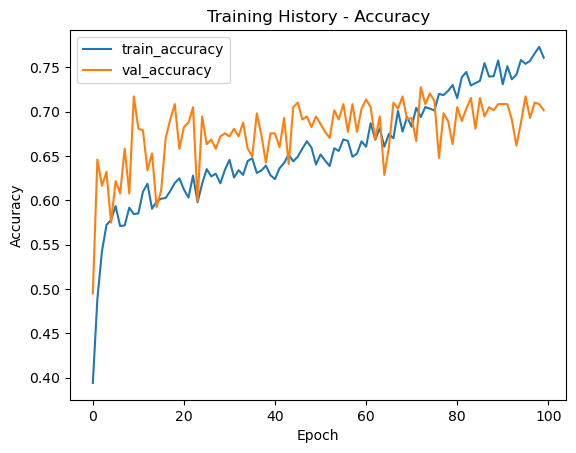

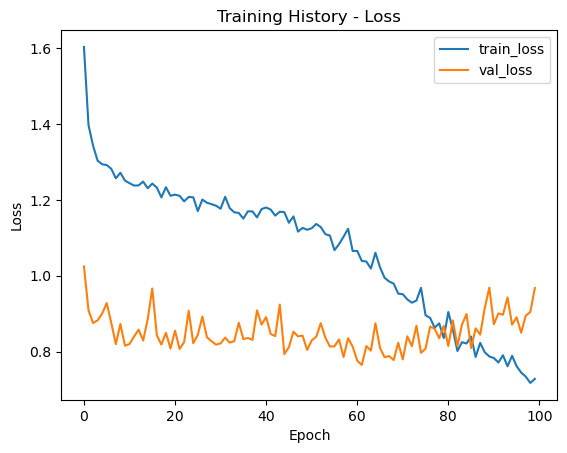

In [33]:
# Visualize training history
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Training History - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training History - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Holdout Test Data

In [32]:
# Hold-out test data generator
test_holdout_datagen = ImageDataGenerator(rescale=1./255)

test_holdout_generator = test_holdout_datagen.flow_from_dataframe(
    dataframe=test_data,
    directory="./Dataset/train_images/",
    x_col="id_code",
    y_col="diagnosis",
    target_size=(256, 256),
    batch_size=32,
    class_mode="categorical",
    shuffle=False  # To keep the order of predictions consistent
)

Found 731 validated image filenames belonging to 5 classes.


C:\Users\MSI\anaconda3\envs\DataAnalytics\lib\site-packages\keras_preprocessing\image\dataframe_iterator.py:282: UserWarning: Found 2 invalid image filename(s) in x_col="id_code". These filename(s) will be ignored.
  .format(n_invalid, x_col)


In [34]:
# Evaluate the model on the hold-out test set
test_holdout_generator.reset()
holdout_test_predictions = model.predict(test_holdout_generator, steps=test_holdout_generator.n // test_holdout_generator.batch_size + 1, verbose=1)
holdout_test_true_labels = test_holdout_generator.classes
holdout_test_pred_labels = np.argmax(holdout_test_predictions, axis=1)

23/23 [==============================] - 83s 4s/step


In [35]:
# Confusion matrix and classification report
conf_matrix = confusion_matrix(holdout_test_true_labels, holdout_test_pred_labels)
class_report = classification_report(holdout_test_true_labels, holdout_test_pred_labels)

print("Confusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(class_report)

Confusion Matrix:
[[329   6   8   2   4]
 [  6  29  11   2  20]
 [ 12  16 115  15  55]
 [  3   1  15   6  11]
 [  4   6  20   5  30]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       349
           1       0.50      0.43      0.46        68
           2       0.68      0.54      0.60       213
           3       0.20      0.17      0.18        36
           4       0.25      0.46      0.32        65

    accuracy                           0.70       731
   macro avg       0.51      0.51      0.50       731
weighted avg       0.72      0.70      0.70       731



In [36]:
#confusion matrix

num_of_train_samples = 2334
num_of_val_samples = 583
num_of_test_samples = 731

batch_size = 32

#Confution Matrix and 
Y_pred = model.predict(test_holdout_generator, num_of_test_samples // batch_size+1)
y_pred = np.argmax(Y_pred, axis=1)
print('Confusion Matrix')

cm = confusion_matrix(test_holdout_generator.classes, y_pred)
print(cm)

#Classification Report

print('Classification Report')
target_names = ['0 - No DR', '1 - Mild', '2 - Moderate', '3 - Severe', '4 - Proliferative DR']
print(classification_report(test_holdout_generator.classes, y_pred, target_names=target_names))

Confusion Matrix
[[329   6   8   2   4]
 [  6  29  11   2  20]
 [ 12  16 115  15  55]
 [  3   1  15   6  11]
 [  4   6  20   5  30]]
Classification Report
                      precision    recall  f1-score   support

           0 - No DR       0.93      0.94      0.94       349
            1 - Mild       0.50      0.43      0.46        68
        2 - Moderate       0.68      0.54      0.60       213
          3 - Severe       0.20      0.17      0.18        36
4 - Proliferative DR       0.25      0.46      0.32        65

            accuracy                           0.70       731
           macro avg       0.51      0.51      0.50       731
        weighted avg       0.72      0.70      0.70       731



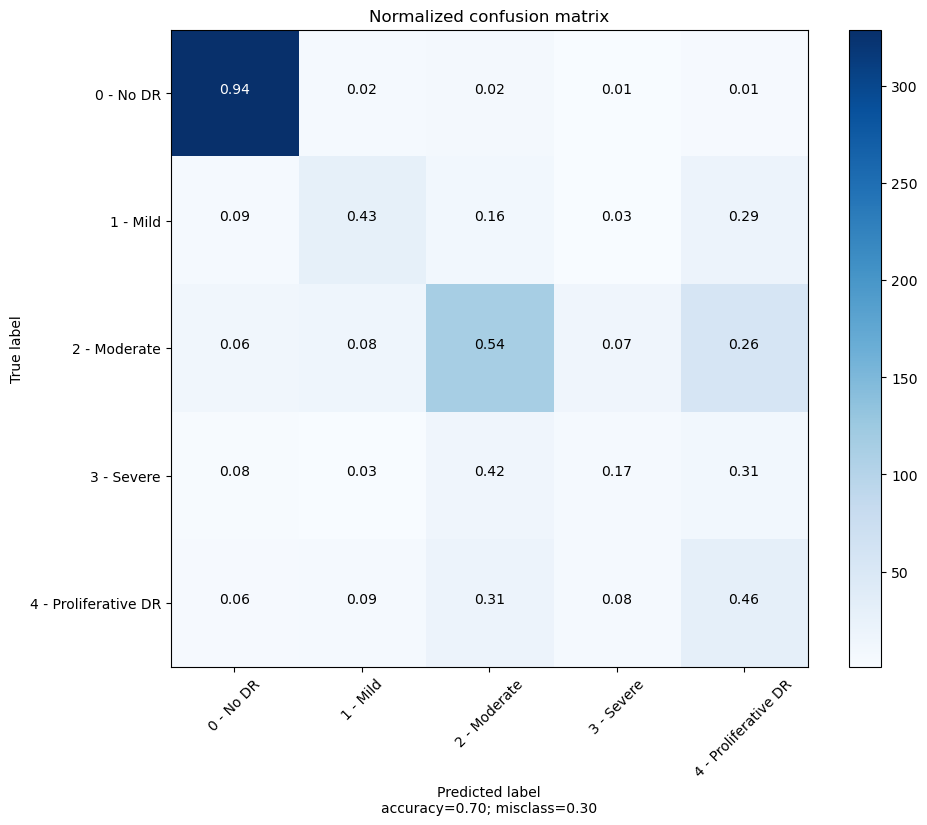

In [37]:
def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):
  
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / np.sum(cm).astype('float')
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.2f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "white")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.2f}; misclass={:0.2f}'.format(accuracy, misclass))
    plt.show()
  
plot_confusion_matrix(cm, target_names=target_names, normalize=True, title='Normalized confusion matrix')

In [39]:
print("Model evalution result --> Test Data")
model.evaluate(test_holdout_generator)

Model evalution result --> Test Data
23/23 [==============================] - 80s 3s/step - loss: 1.1241 - accuracy: 0.6963


[1.1240988969802856, 0.6963064074516296]